# Exercise 4

## Imports and Configuration
We load libraries for hyperspectral processing, STAC discovery, and statistical analysis.

In [1]:
# !uv pip install rasterio spectral pystac_client planetary_computer

In [55]:
import os
from datetime import datetime, timedelta
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from skimage.transform import resize
from rasterio.warp import transform
from rasterio.windows import from_bounds, Window
import spectral.io.envi as envi
from pystac_client import Client
from pyproj import Transformer
import planetary_computer
from scipy.stats import linregress

import warnings
warnings.filterwarnings('ignore')

ACQUISITION_DATE = '2025-06-17'

print("Libraries imported successfully.")


Libraries imported successfully.


Solve windows problems
![lol](https://i.redd.it/im-tired-boss-the-green-mile-v0-5n6l9b34iecg1.jpg?width=1920&format=pjpg&auto=webp&s=40328510925c2b7573b90bf1e1a923d77ecba0cd)

In [ ]:
# !pip uninstall rasterio pyproj -y
# !pip install rasterio pyproj

In [24]:
os.environ["PROJ_LIB"] = r"E:\github_repos\eolabs\.venv\Lib\site-packages\rasterio\proj_data"
os.environ["PROJ_LIB"]

'E:\\github_repos\\eolabs\\.venv\\Lib\\site-packages\\rasterio\\proj_data'

## Loading Airborne Data

In [12]:
LAB_5_DIR = Path().cwd() / "lab_5"
BASE_DIR = LAB_5_DIR / "data" / "you-shall-not-pass" / "Obrazy lotnicze"
print(BASE_DIR)
hdr_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr'
bsq_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.bsq'

E:\github_repos\eolabs\lab_5\data\you-shall-not-pass\Obrazy lotnicze


In [ ]:
if hdr_path.exists():
    img = envi.open(hdr_path)
    print(f"Opened airborne cube: {hdr_path.name}")
    print(f"Shape: {img.shape}")
    
    # Since the cubes are large and memory overload is totally possible
    # only a subset is loaded
    cy, cx = img.nrows // 2, img.ncols // 2
    r_start, r_end = cy - 250, cy + 250
    c_start, c_end = cx - 250, cx + 250
    airborne_cube = img.read_subregion((r_start, r_end), (c_start, c_end))
    
    # Get wavelengths
    wavelengths = np.array([float(x) for x in img.metadata['wavelength']])
    print(f"Loaded subset shape: {airborne_cube.shape}")
else:
    print("Airborne data not found")

Opened airborne cube: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Shape: (4300, 2001, 456)
Loaded subset shape: (500, 500, 456)


Extract bounding box for sentinel 2 data - step learnt by a whole lot of problems

In [25]:
with rasterio.open(bsq_path) as src:
    # IMPORTANT: Window uses (col, row), not (row, col)
    air_win = Window(
        c_start,                # col_off
        r_start,                # row_off
        c_end - c_start,        # width
        r_end - r_start         # height
    )

    # Get bounds in native CRS
    air_left, air_bottom, air_right, air_top = src.window_bounds(air_win)

    # Convert to EPSG:4326 (lat/lon)
    lons, lats = transform(
        src.crs,
        "EPSG:4326",
        [air_left, air_right],
        [air_bottom, air_top]
    )

    subset_bbox = [lons[0], lats[0], lons[1], lats[1]]

print("subset_bbox:", subset_bbox)

subset_bbox: [18.14731151591121, 50.34058567596257, 18.154350257213924, 50.3450718571218]


## Description of Methods

Different land cover types (water, forest, green areas) are loaded as reference spectra for SAM.

In [5]:
sig_dir = LAB_5_DIR / "spectral_signatures"
sig_files = list(sig_dir.glob('*.csv'))

spectra = {}
for f in sig_files:
    class_name = f.stem.rstrip('1234567890')
    df = pd.read_csv(f)
    if class_name not in spectra: spectra[class_name] = []
    spectra[class_name].append(df['value'].values)

# Calculate mean spectra for each class
reference_spectra = {k: np.nanmean(v, axis=0) for k, v in spectra.items()}
print(f"Reference classes: {list(reference_spectra.keys())}")

Reference classes: ['forest', 'green', 'water']


## Spectral Angle Mapper (SAM)

SAM calculates the spectral similarity between a reference spectrum and each pixel by computing the angle between them in a multidimensional spectral space. 

Smaller angles indicate higher similarity.

In this case SAM can distinguish between different types of water, which can show the contamination

It's calculated, because while the same pixel can appear brighter/darker based on conditions, but it will not change the spectral signature significantly, which can help identify different materials

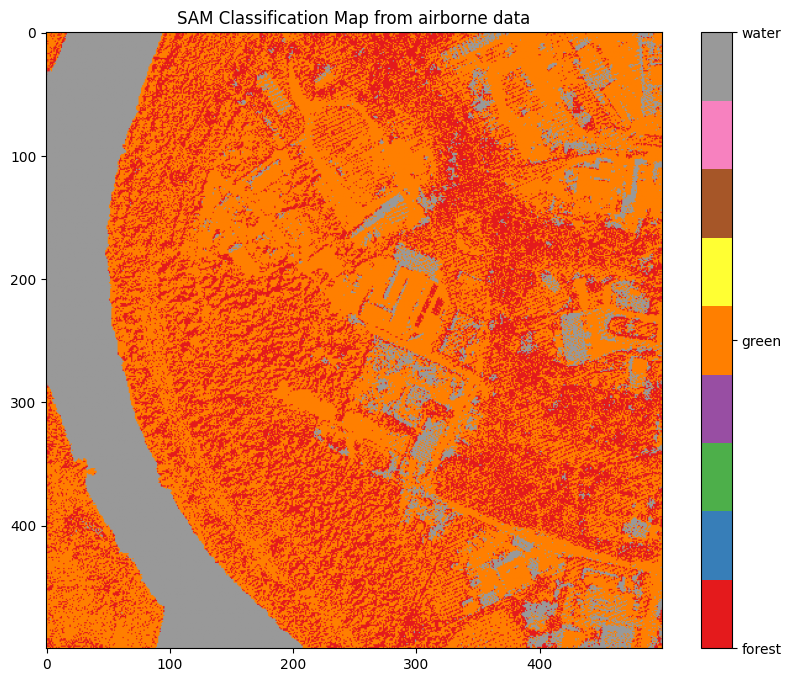

In [6]:
def compute_sam(hypercube, ref_spectrum):
    # ref_spectrum might need interpolation if band counts differ
    if len(ref_spectrum) != hypercube.shape[2]:
        ref_spectrum = np.interp(
            np.linspace(0, 1, hypercube.shape[2]), 
            np.linspace(0, 1, len(ref_spectrum)), 
            ref_spectrum
        )
    
    dot_product = np.sum(hypercube * ref_spectrum, axis=2)
    norm_cube = np.sqrt(np.sum(hypercube**2, axis=2))
    norm_ref = np.sqrt(np.sum(ref_spectrum**2))
    cos_theta = dot_product / (norm_cube * norm_ref + 1e-8)
    # clip values to arcos range to avoid numerical issues
    return np.arccos(np.clip(cos_theta, -1.0, 1.0))

# each class is applied the SAM
sam_maps = {k: compute_sam(airborne_cube, ref) for k, ref in reference_spectra.items()}

# minimal angle is used to classify pixels
class_names = list(sam_maps.keys())
stacked_angles = np.stack([sam_maps[k] for k in class_names], axis=-1)
classification = np.argmin(stacked_angles, axis=-1)

# plot the SAM classification map
plt.figure(figsize=(10, 8))
im = plt.imshow(classification, cmap='Set1')
cbar = plt.colorbar(im, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
plt.title('SAM Classification Map from airborne data')
plt.show()

As it can be seen there are the three classes visible, the colorbar is a bit off (the intuition is not your friend here, but it actually got the classses right)

More classes should have been defined for instance fields and buildings, as they might blend and be considered water, which is a case here

## Fetch Sentinel-2 Data for aquisition date

**2025-07-17**

SSL workaround, seems that I need it every time I use pystack on my Windows machine

In [7]:
import certifi
import os

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [30]:
target_date = datetime.strptime(ACQUISITION_DATE, "%Y-%m-%d")
start_date = (target_date - timedelta(days=7)).strftime("%Y-%m-%d")
end_date = (target_date + timedelta(days=7)).strftime("%Y-%m-%d")

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", 
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=subset_bbox,
    datetime=f"{start_date}/{end_date}",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = list(search.items())
if items:
    best_item = items[0]
    print(f"Found Sentinel-2 item: {best_item.id}")
    
    # Access bands for RGB + NIR
    assets = best_item.assets
    b_blue = assets['B02'].href
    b_green = assets['B03'].href
    b_red = assets['B04'].href
    b_nir = assets['B08'].href
    
    print("loaded bands")
else:
    print("couldn't load bands")

Found Sentinel-2 item: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401
loaded bands


Again two days off

#### Display Sentinel 2 images

to confirm the area is correct...

In [34]:
data = {}

with rasterio.open(b_red) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    minx, miny = transformer.transform(subset_bbox[0], subset_bbox[1])
    maxx, maxy = transformer.transform(subset_bbox[2], subset_bbox[3])

    win = from_bounds(minx, miny, maxx, maxy, src.transform)
    shape = (500, 500)

    data["red"] = src.read(1, window=win, out_shape=shape).astype("float32") / 10000.0

with rasterio.open(b_green) as src:
    data["green"] = src.read(1, window=win, out_shape=shape).astype("float32") / 10000.0

with rasterio.open(b_blue) as src:
    data["blue"] = src.read(1, window=win, out_shape=shape).astype("float32") / 10000.0

with rasterio.open(b_nir) as src:
    data["nir"] = src.read(1, window=win, out_shape=shape).astype("float32") / 10000.0

print("loaded data")

loaded data


power function for stretching values (useful for plotting)

In [31]:
def stretch(img, p_low=2, p_high=98):
    lo, hi = np.percentile(img, (p_low, p_high))
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

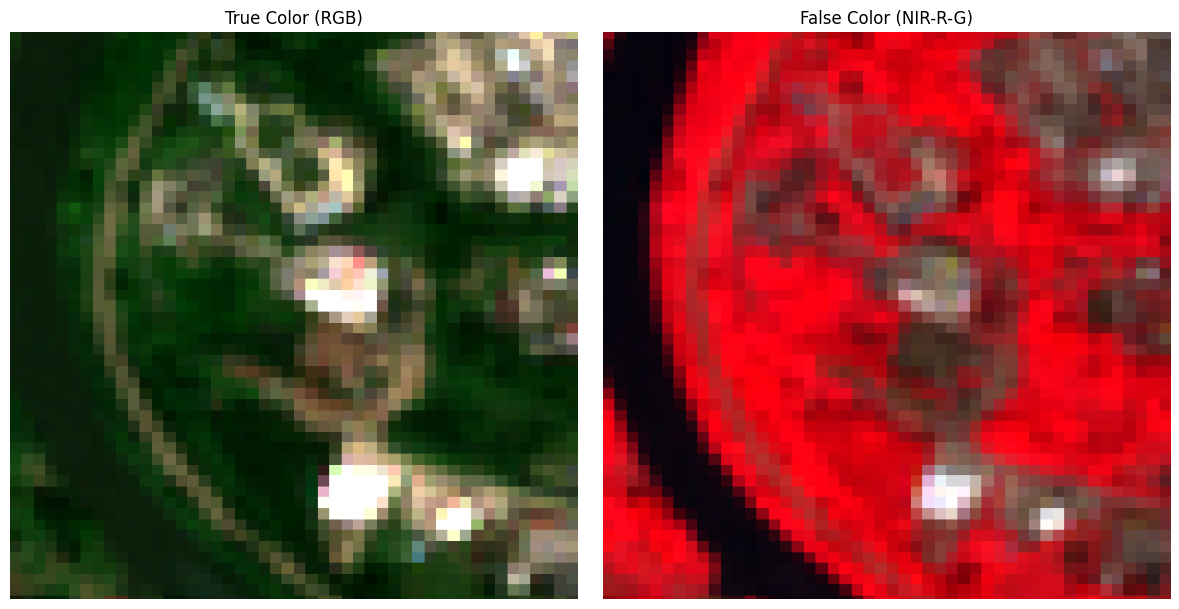

In [36]:
# create images out of the bands
rgb = np.dstack([data["red"], data["green"], data["blue"]])
false_color = np.dstack([data["nir"], data["red"], data["green"]])

rgb_stretch = stretch(rgb)
fc_stretch = stretch(false_color)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_stretch)
axes[0].set_title("True Color (RGB)")
axes[0].axis("off")

axes[1].imshow(fc_stretch)
axes[1].set_title("False Color (NIR-R-G)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

You can clearly see the difference between 10m vs 1m resolution

## Calibrate Sentinel-2 using Airborne Data

I'll use linear regression to calibrate the sentinel 2 data, as both EO methods measure the same area and same properities of water so we could potentially use airborne model as a baseline for data with lower resolution

##### 1. Get bands so that we can compare indices from previous tasks, ultimately that's the goal of analyses so the model HAS to take that into consideration

###### Sentinel 2 indices

that's really small (H6)

In [38]:
chla_s2 = data["nir"] / (data["red"] + 1e-6)
doc_s2  = data["green"] / (data["red"] + 1e-6)
turb_s2 = data["nir"]

###### Airborne - band extraction + indices

In [37]:
idx_705 = np.argmin(np.abs(wavelengths - 705))
idx_665 = np.argmin(np.abs(wavelengths - 665))
idx_490 = np.argmin(np.abs(wavelengths - 490))
idx_560 = np.argmin(np.abs(wavelengths - 560))
idx_750 = np.argmin(np.abs(wavelengths - 750))

chla_air = airborne_cube[:, :, idx_705] / (airborne_cube[:, :, idx_665] + 1e-6)
doc_air  = airborne_cube[:, :, idx_665] / (airborne_cube[:, :, idx_490] + 1e-6)
turb_air = airborne_cube[:, :, idx_750]

##### 2. we need matching sizes of images so that they can be used in the same calculation/modelling 

In [45]:
# hyperspectral -> multispectral, that's the resizing order
target_shape = data["red"].shape

chla_air_res = resize(chla_air, target_shape, order=1, preserve_range=True)
doc_air_res  = resize(doc_air, target_shape, order=1, preserve_range=True)
turb_air_res = resize(turb_air, target_shape, order=1, preserve_range=True)

##### 3. create a function that will create a model for the data
please note that we only use elements that are finite, infinity is of no use here :D

In [46]:
def fit_calibration(x_air, x_s2):
    mask = np.isfinite(x_air) & np.isfinite(x_s2)

    X = x_s2[mask].reshape(-1, 1)
    y = x_air[mask]

    # airborne data is the target!


    model = LinearRegression()
    model.fit(X, y)

    return model

##### 4. create models and predict new values

In [50]:
model_chla = fit_calibration(chla_air_res, chla_s2)
model_doc  = fit_calibration(doc_air_res, doc_s2)
model_turb = fit_calibration(turb_air_res, turb_s2)

# use the models to create calibrated indices
chla_s2_cal = model_chla.predict(chla_s2.reshape(-1, 1)).reshape(target_shape)
doc_s2_cal  = model_doc.predict(doc_s2.reshape(-1, 1)).reshape(target_shape)
turb_s2_cal = model_turb.predict(turb_s2.reshape(-1, 1)).reshape(target_shape)

##### 5. show the data along its calibrated version

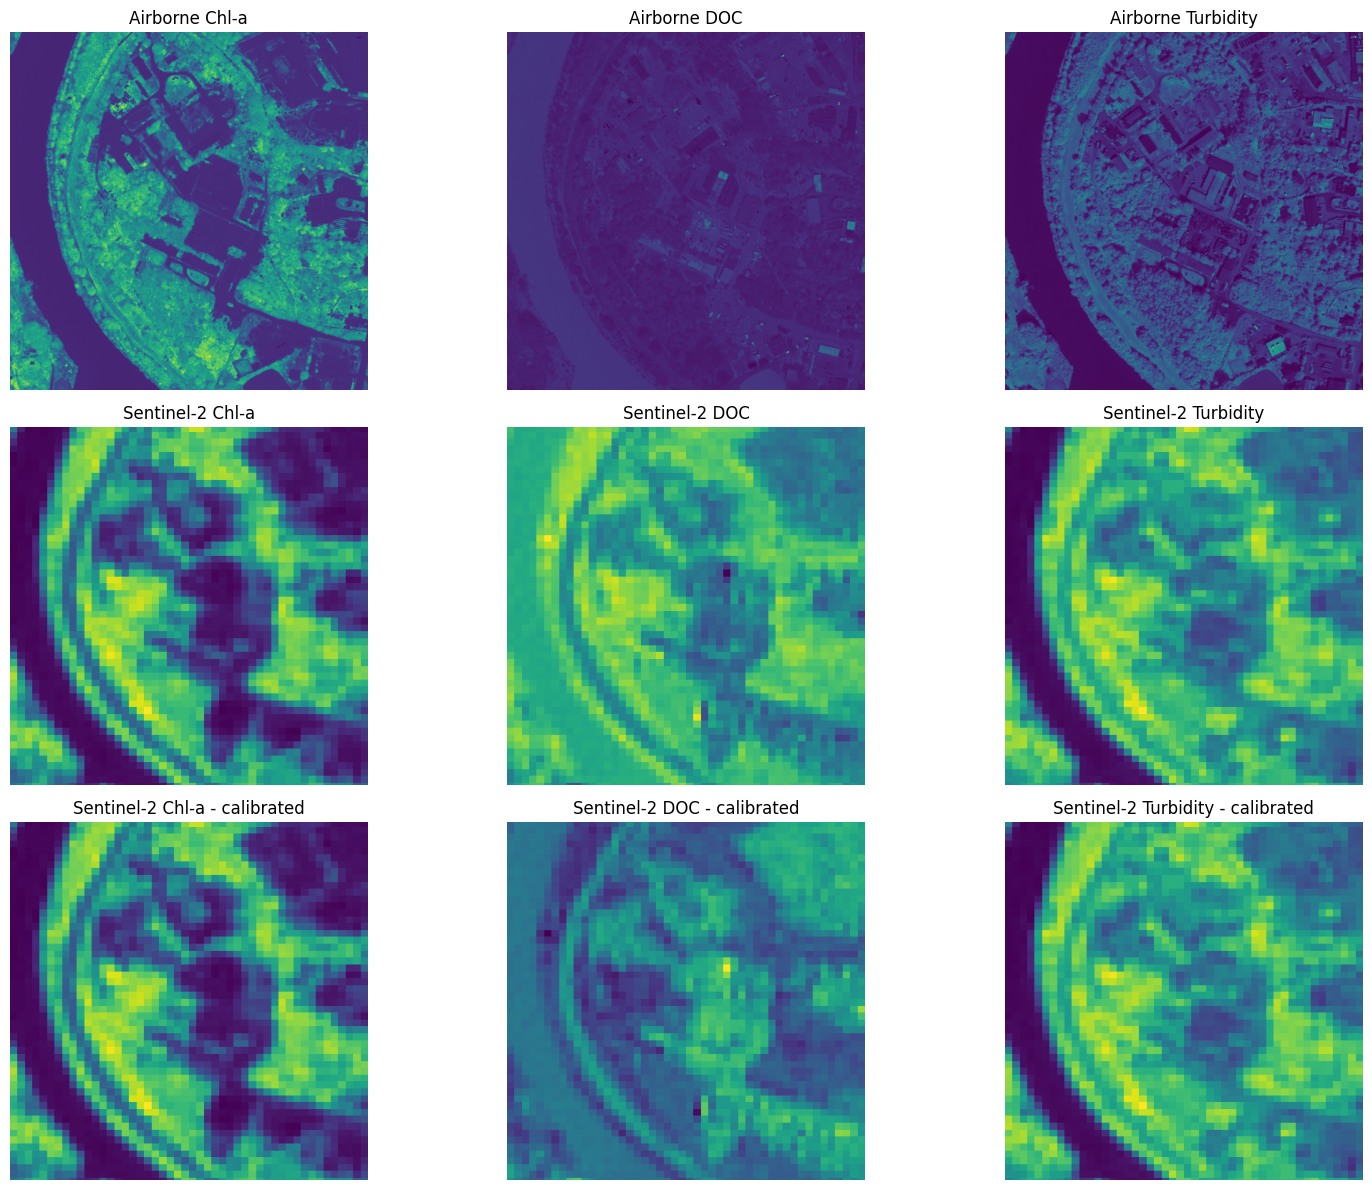

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

axes[0,0].imshow(chla_air_res, cmap="viridis")
axes[0,0].set_title("Airborne Chl-a")

axes[0,1].imshow(doc_air_res, cmap="viridis")
axes[0,1].set_title("Airborne DOC")

axes[0,2].imshow(turb_air_res, cmap="viridis")
axes[0,2].set_title("Airborne Turbidity")

axes[1,0].imshow(chla_s2, cmap="viridis")
axes[1,0].set_title("Sentinel-2 Chl-a")

axes[1,1].imshow(doc_s2, cmap="viridis")
axes[1,1].set_title("Sentinel-2 DOC")

axes[1,2].imshow(turb_s2, cmap="viridis")
axes[1,2].set_title("Sentinel-2 Turbidity")

axes[2,0].imshow(chla_s2_cal, cmap="viridis")
axes[2,0].set_title("Sentinel-2 Chl-a - calibrated")

axes[2,1].imshow(doc_s2_cal, cmap="viridis")
axes[2,1].set_title("Sentinel-2 DOC - calibrated")

axes[2,2].imshow(turb_s2_cal, cmap="viridis")
axes[2,2].set_title("Sentinel-2 Turbidity - calibrated")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Analysis/Comparison
It's worth noting that at time of writing the initial comment there's a difference in indices for airborne and sentinel 2 data, which I will get on top of (soon). However what can be seen is the influence of calibration on indices, first and foremost for DOC the change is clearily visible, the colors have shifted slightly and resemble airborne indices more which shows that the linear regression actually "translates the values" from one image to the other - that's expected and wanted in this case.

For ChI-a it's mroe similiar in terms of colors, but a bit sharper in the calibrated version, which shows that the values are somewhat interpolated to resemble the airborne data, for "calibrating" spatial resolution it might actually visually improve the quality, I'll look at values and differences next to see what the calibration has "really" done.

In [56]:
chla_diff = chla_s2_cal - chla_s2
doc_diff  = doc_s2_cal - doc_s2
turb_diff = turb_s2_cal - turb_s2

In [59]:
def improvement_map(air, raw, cal):
    mask = np.isfinite(air) & np.isfinite(raw) & np.isfinite(cal)

    err_raw = np.abs(air - raw)
    err_cal = np.abs(air - cal)

    # mask needs to be used
    out = np.zeros_like(air)
    out[:] = np.nan

    out[mask] = err_raw[mask] - err_cal[mask]

    return out

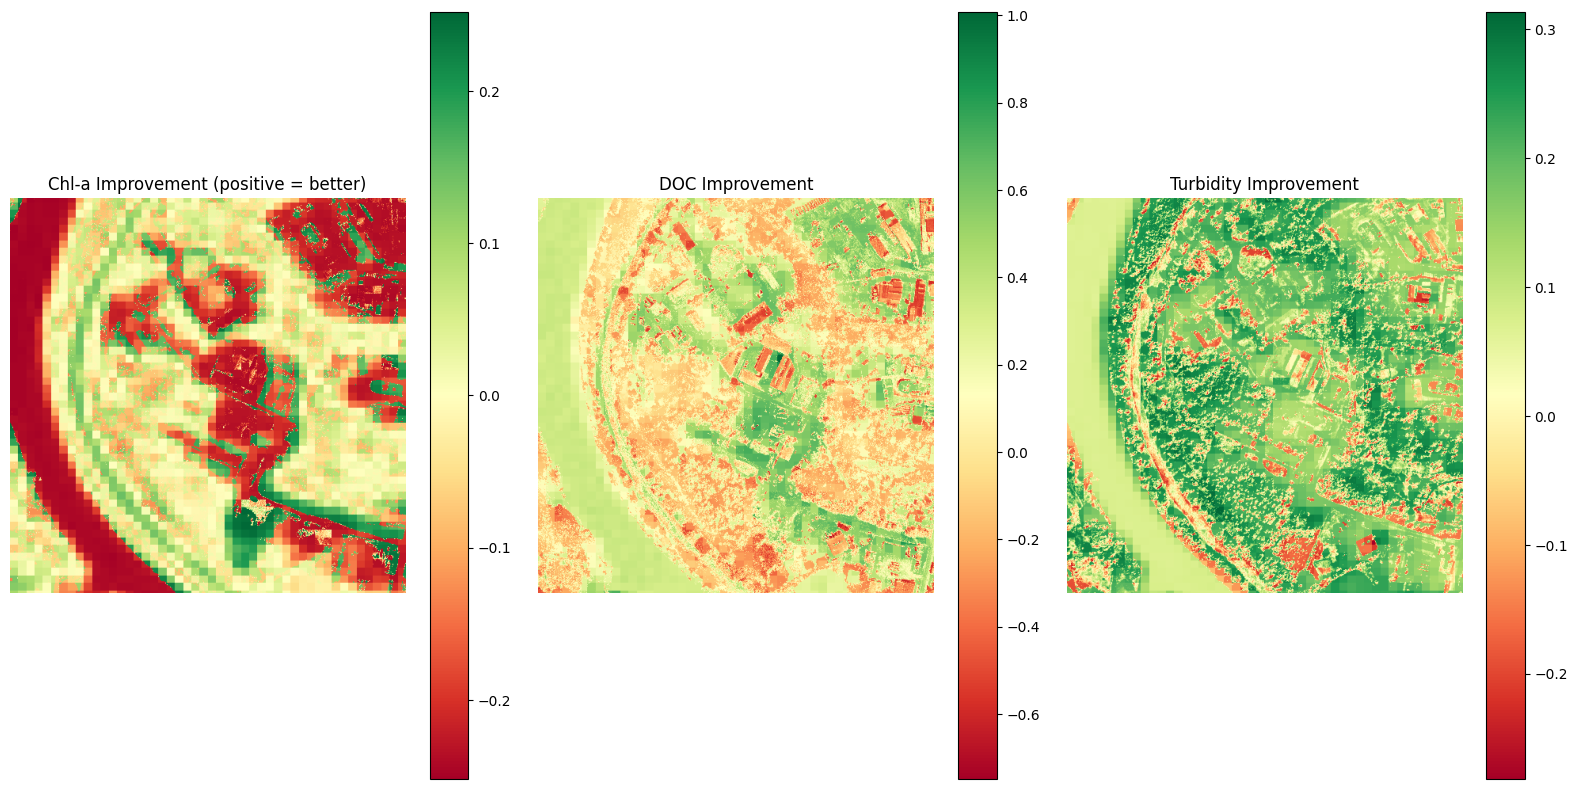

In [60]:
chla_imp = improvement_map(chla_air_res, chla_s2, chla_s2_cal)
doc_imp  = improvement_map(doc_air_res, doc_s2, doc_s2_cal)
turb_imp = improvement_map(turb_air_res, turb_s2, turb_s2_cal)

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

im0 = axes[0].imshow(chla_imp, cmap="RdYlGn")
axes[0].set_title("Chl-a Improvement (positive = better)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(doc_imp, cmap="RdYlGn")
axes[1].set_title("DOC Improvement")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(turb_imp, cmap="RdYlGn")
axes[2].set_title("Turbidity Improvement")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Positive is considered an improvement, because it's closer to the airborne data, if it's negative it actually moved away from the high spatial resolution image and therefore the error increases. It's a bit of a stretch but is a good enough example for the case. Only for ChI-a the change is negativ, because there is much more noise.